# Real-Time Anomaly Detection in Big Data Streams Using LSTM Autoencoders
### A Distributed Processing Approach

**Student ID:** 2026257
**Module:** Advanced Data Analytics / Big Data Storage and Processing, Integrated CA1 Sem 2
**Dataset:** Credit Card Fraud Detection (Kaggle, mlg-ulb/creditcardfraud)


## 0. Environment Setup

In [10]:
# !pip install pyspark==3.5.1 tensorflow scikit-learn pandas matplotlib seaborn kagglehub --quiet
print("Skip re-running if packages are already installed.")


Skip re-running if packages are already installed.


In [11]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_auc_score, roc_curve, f1_score
)

print("PySpark:", pyspark.__version__, "| TensorFlow:", tf.__version__)


PySpark: 4.0.4 | TensorFlow: 2.21.0


## 1. Initialize Spark Session (Big Data Component)


In [12]:
spark = (
    SparkSession.builder
    .appName("CA1_BigData_NeuralNetworks")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark


## 2. Load Dataset

Download `creditcard.csv` from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


In [13]:
import os, glob

candidates = glob.glob("*.csv") + glob.glob("/content/*.csv") + glob.glob("/content/sample_data/*.csv")
candidates = [c for c in candidates if "sample_data" not in c or "creditcard" in c.lower()]

if candidates:
    csv_path = candidates[0]
    print("Auto-detected dataset file:", csv_path)
else:
    csv_path = "/content/creditcard.csv"
    print("No CSV auto-detected -- make sure 'creditcard.csv' is uploaded, or set csv_path manually.")

df_spark = spark.read.csv(csv_path, header=True, inferSchema=True)
df_spark.printSchema()
print("Row count:", df_spark.count())
df_spark.show(5)


Auto-detected dataset file: creditcard.csv
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: doubl

## 3. Exploratory Data Analysis (Distributed + Local)



In [14]:
null_counts = df_spark.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_spark.columns])
null_counts.show()


+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



   Class   count
0      1     492
1      0  284315
Fraud cases: 0.1727% of total — highly imbalanced, hence an UNSUPERVISED approach.


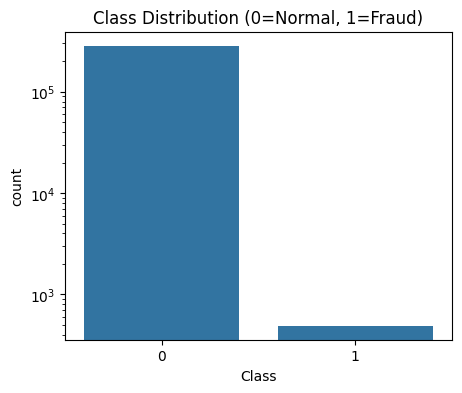

In [15]:
label_col = "Class"  # 0 = normal, 1 = fraud

class_counts = df_spark.groupBy(label_col).count().toPandas()
print(class_counts)

fraud_pct = class_counts.loc[class_counts[label_col] == 1, "count"].values[0] / class_counts["count"].sum() * 100
print(f"Fraud cases: {fraud_pct:.4f}% of total — highly imbalanced, hence an UNSUPERVISED approach.")

plt.figure(figsize=(5,4))
sns.barplot(x=label_col, y="count", data=class_counts)
plt.title("Class Distribution (0=Normal, 1=Fraud)")
plt.yscale("log")
plt.show()


In [16]:
amount_summary = df_spark.groupBy(label_col).agg(
    F.mean("Amount").alias("mean_amount"),
    F.stddev("Amount").alias("std_amount"),
    F.max("Amount").alias("max_amount")
).toPandas()
print(amount_summary)


   Class  mean_amount  std_amount  max_amount
0      1   122.211321  256.683288     2125.87
1      0    88.291022  250.105092    25691.16


## 4. Distributed Preprocessing → Model-Ready Data

Spark handles the ETL stage. We then hand off a cleaned, scaled array to the deep learning
framework — this reflects a realistic big-data-to-ML pipeline pattern.


In [17]:
df = df_spark.toPandas()  # handoff point: Spark -> Pandas/NumPy for DL training

feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].values
y = df[label_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

print("Train (normal only):", X_train.shape, "| Val:", X_val.shape, "| Full (for testing):", X_scaled.shape)


Train (normal only): (227452, 30) | Val: (56863, 30) | Full (for testing): (284807, 30)


## 5. Shared Evaluation Function

In [18]:
def evaluate_autoencoder(model, X_all, y_all, label="Model", threshold=None, threshold_percentile=95):
    reconstructions = model.predict(X_all, verbose=0)
    mse = np.mean(np.power(X_all.reshape(X_all.shape[0], -1) - reconstructions.reshape(reconstructions.shape[0], -1), 2), axis=1)

    if threshold is None:
        threshold = np.percentile(mse, threshold_percentile)

    y_pred = (mse > threshold).astype(int)

    print(f"--- {label} ---")
    print("Threshold used:", threshold)
    print(classification_report(y_all, y_pred, digits=4))
    auc = roc_auc_score(y_all, mse)
    f1 = f1_score(y_all, y_pred)
    print(f"ROC-AUC: {auc:.4f} | F1: {f1:.4f}")

    return {"mse": mse, "y_pred": y_pred, "auc": auc, "f1": f1, "threshold": threshold}

results = {}
